In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingRegressor
from sklearn.metrics import (
accuracy_score, classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score,
mean_absolute_error, mean_squared_error, r2_score
)

from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostRegressor

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('global_placement.csv')
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,104124.367838
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,80586.838313
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,114444.318097
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,120000.000000
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,120000.000000


In [4]:
print(f"Shape:{df.shape}")
print(f"Columns:{df.columns}")

Shape:(10000, 13)
Columns:Index(['cgpa', 'backlogs', 'college_tier', 'country',
       'university_ranking_band', 'internship_count', 'aptitude_score',
       'communication_score', 'specialization', 'industry',
       'internship_quality_score', 'placement_status', 'salary'],
      dtype='object')


In [7]:
print(f"Missing values:{df.isnull().sum()}")
print(f"Dupicates:{df.duplicated().sum()}")
print(f"Data Types:{df.dtypes}")
print(f"Summary: {df.describe(include='all')}")

Missing values:cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
salary                      0
dtype: int64
Dupicates:0
Data Types:cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
salary                      float64
dtype: object
Summary:                 cgpa      backlogs college_tier  country  \
count   

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"{col:30s}:{df[col].unique().tolist()}")

college_tier                  :['Tier 2', 'Tier 3', 'Tier 1']
country                       :['Canada', 'UK', 'USA', 'Germany', 'India']
university_ranking_band       :['100-300', '300+', 'Top 100']
specialization                :['Data Science', 'Cybersecurity', 'AI/ML', 'Core CS', 'Cloud']
industry                      :['Consulting', 'Healthcare', 'Tech', 'Manufacturing', 'Other', 'Finance']
placement_status              :['Placed', 'Not Placed']


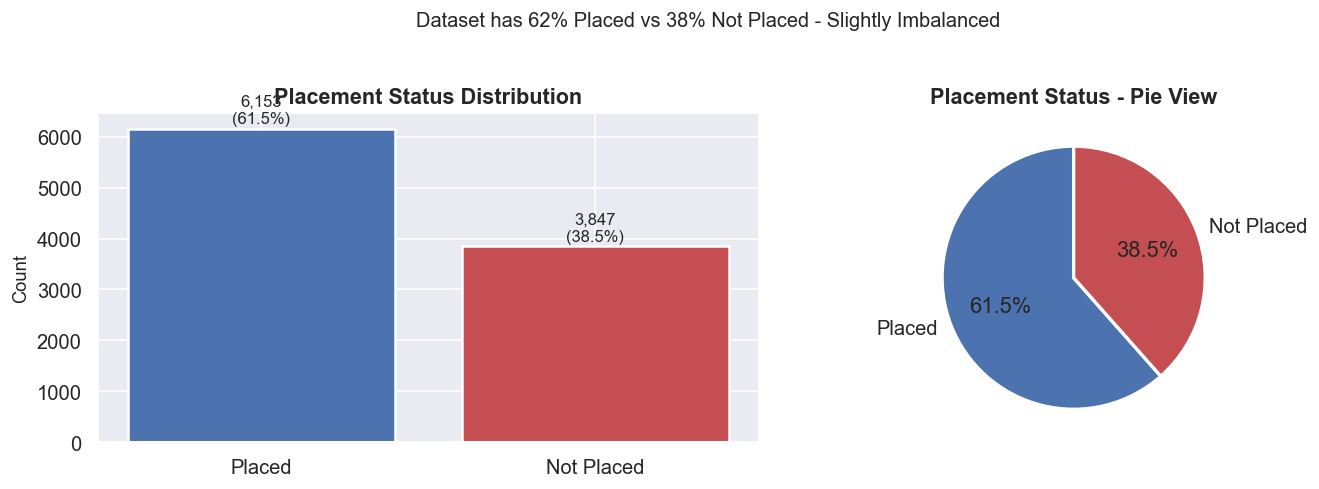

In [11]:
placed_counts = df['placement_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(placed_counts.index, placed_counts.values,
                   color=[PALETTE[0], PALETTE[3]], edgecolor='white', linewidth=1.5)
axes[0].set_title('Placement Status Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, placed_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

axes[1].pie(placed_counts.values, labels=placed_counts.index,
            colors=[PALETTE[0], PALETTE[3]], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Placement Status - Pie View', fontweight='bold')

plt.suptitle('Dataset has 62% Placed vs 38% Not Placed - Slightly Imbalanced',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('placement_status.png')
plt.show()

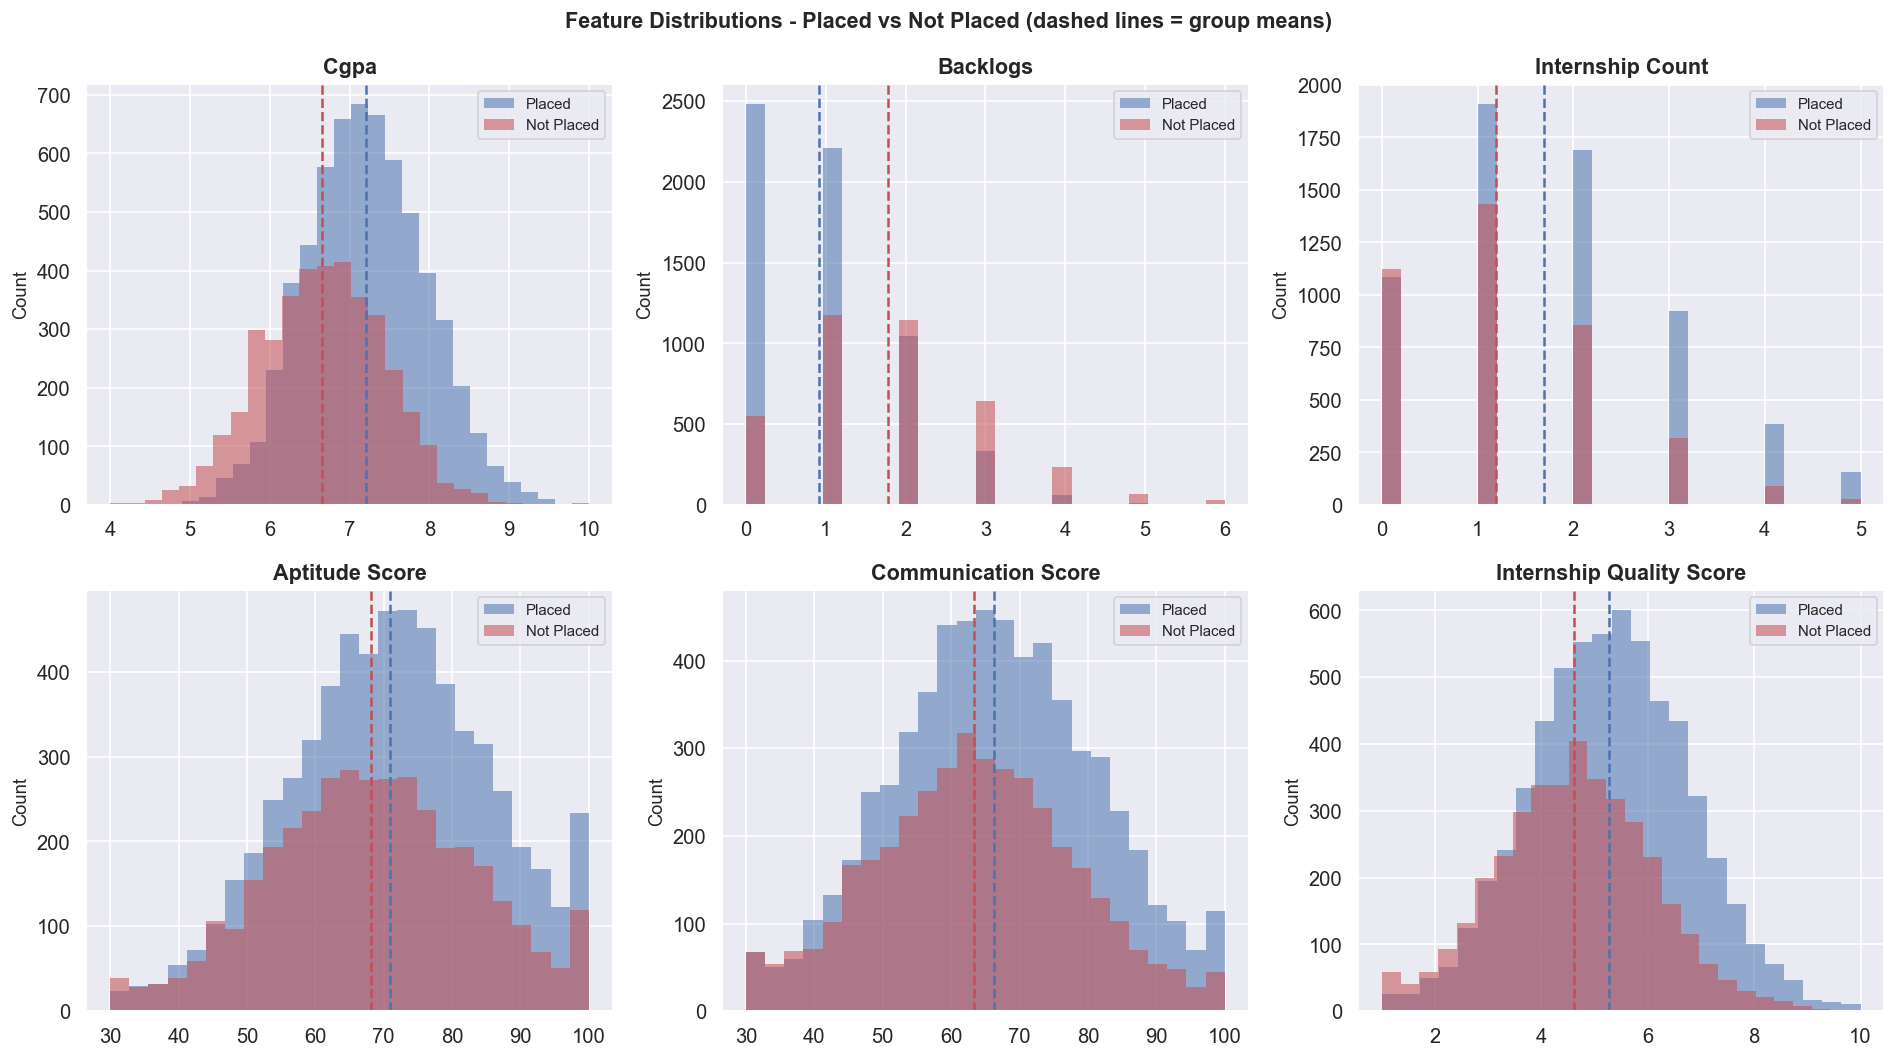

In [12]:
num_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score',
            'communication_score', 'internship_quality_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for status, color in zip(['Placed', 'Not Placed'], [PALETTE[0], PALETTE[3]]):
        subset = df[df['placement_status'] == status][col]
        axes[i].hist(subset, bins=25, alpha=0.55, color=color, label=status, edgecolor='none')
        axes[i].axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions - Placed vs Not Placed (dashed lines = group means)',
             fontsize=13, fontweight='bold')
plt.savefig('Featue_distribution.png')
plt.tight_layout()
plt.show()

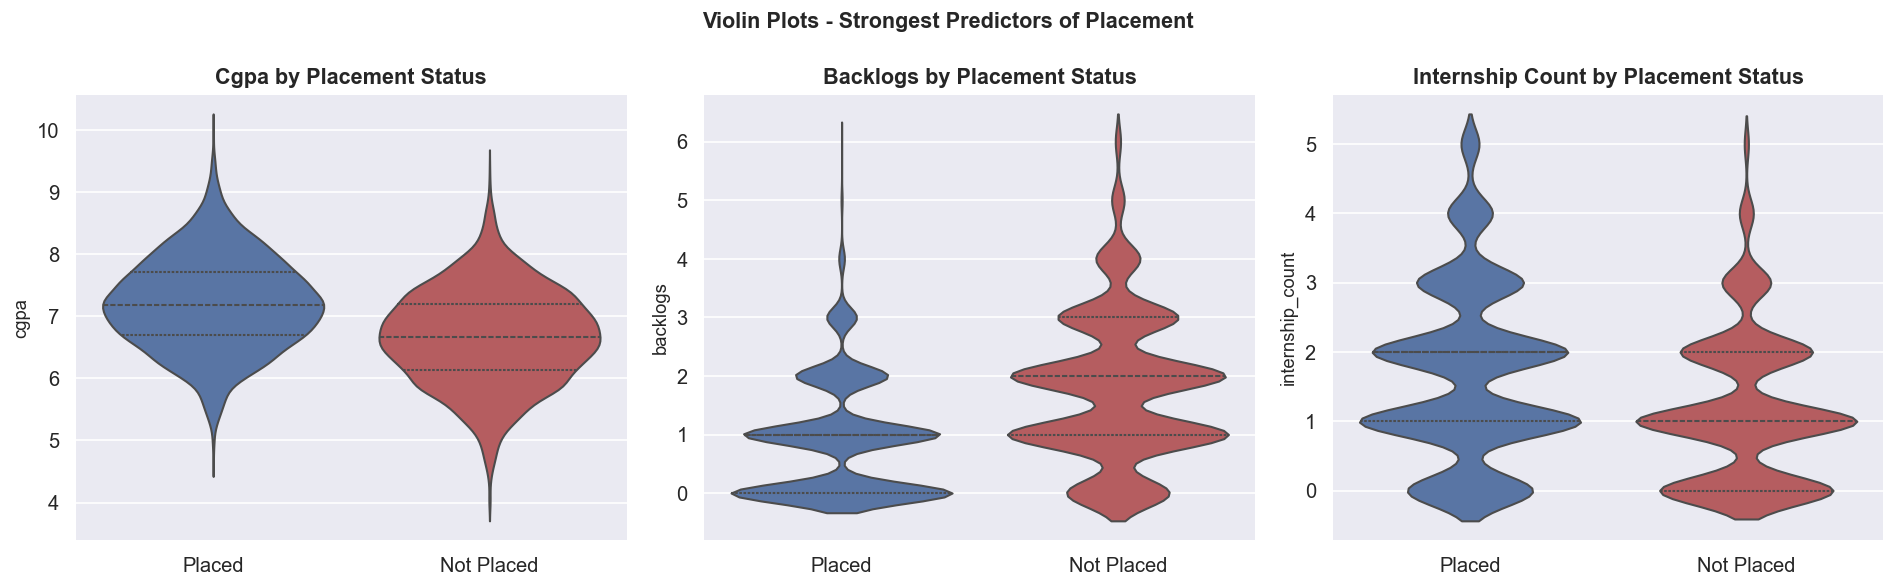

In [13]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax, col in zip(axes, ['cgpa', 'backlogs', 'internship_count']):
    sns.violinplot(data=df, x='placement_status', y=col,
                   palette=[PALETTE[0], PALETTE[3]], ax=ax, inner='quartile')
    ax.set_title(f'{col.replace("_"," ").title()} by Placement Status', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Violin Plots - Strongest Predictors of Placement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Violin_plots.png')
plt.show()

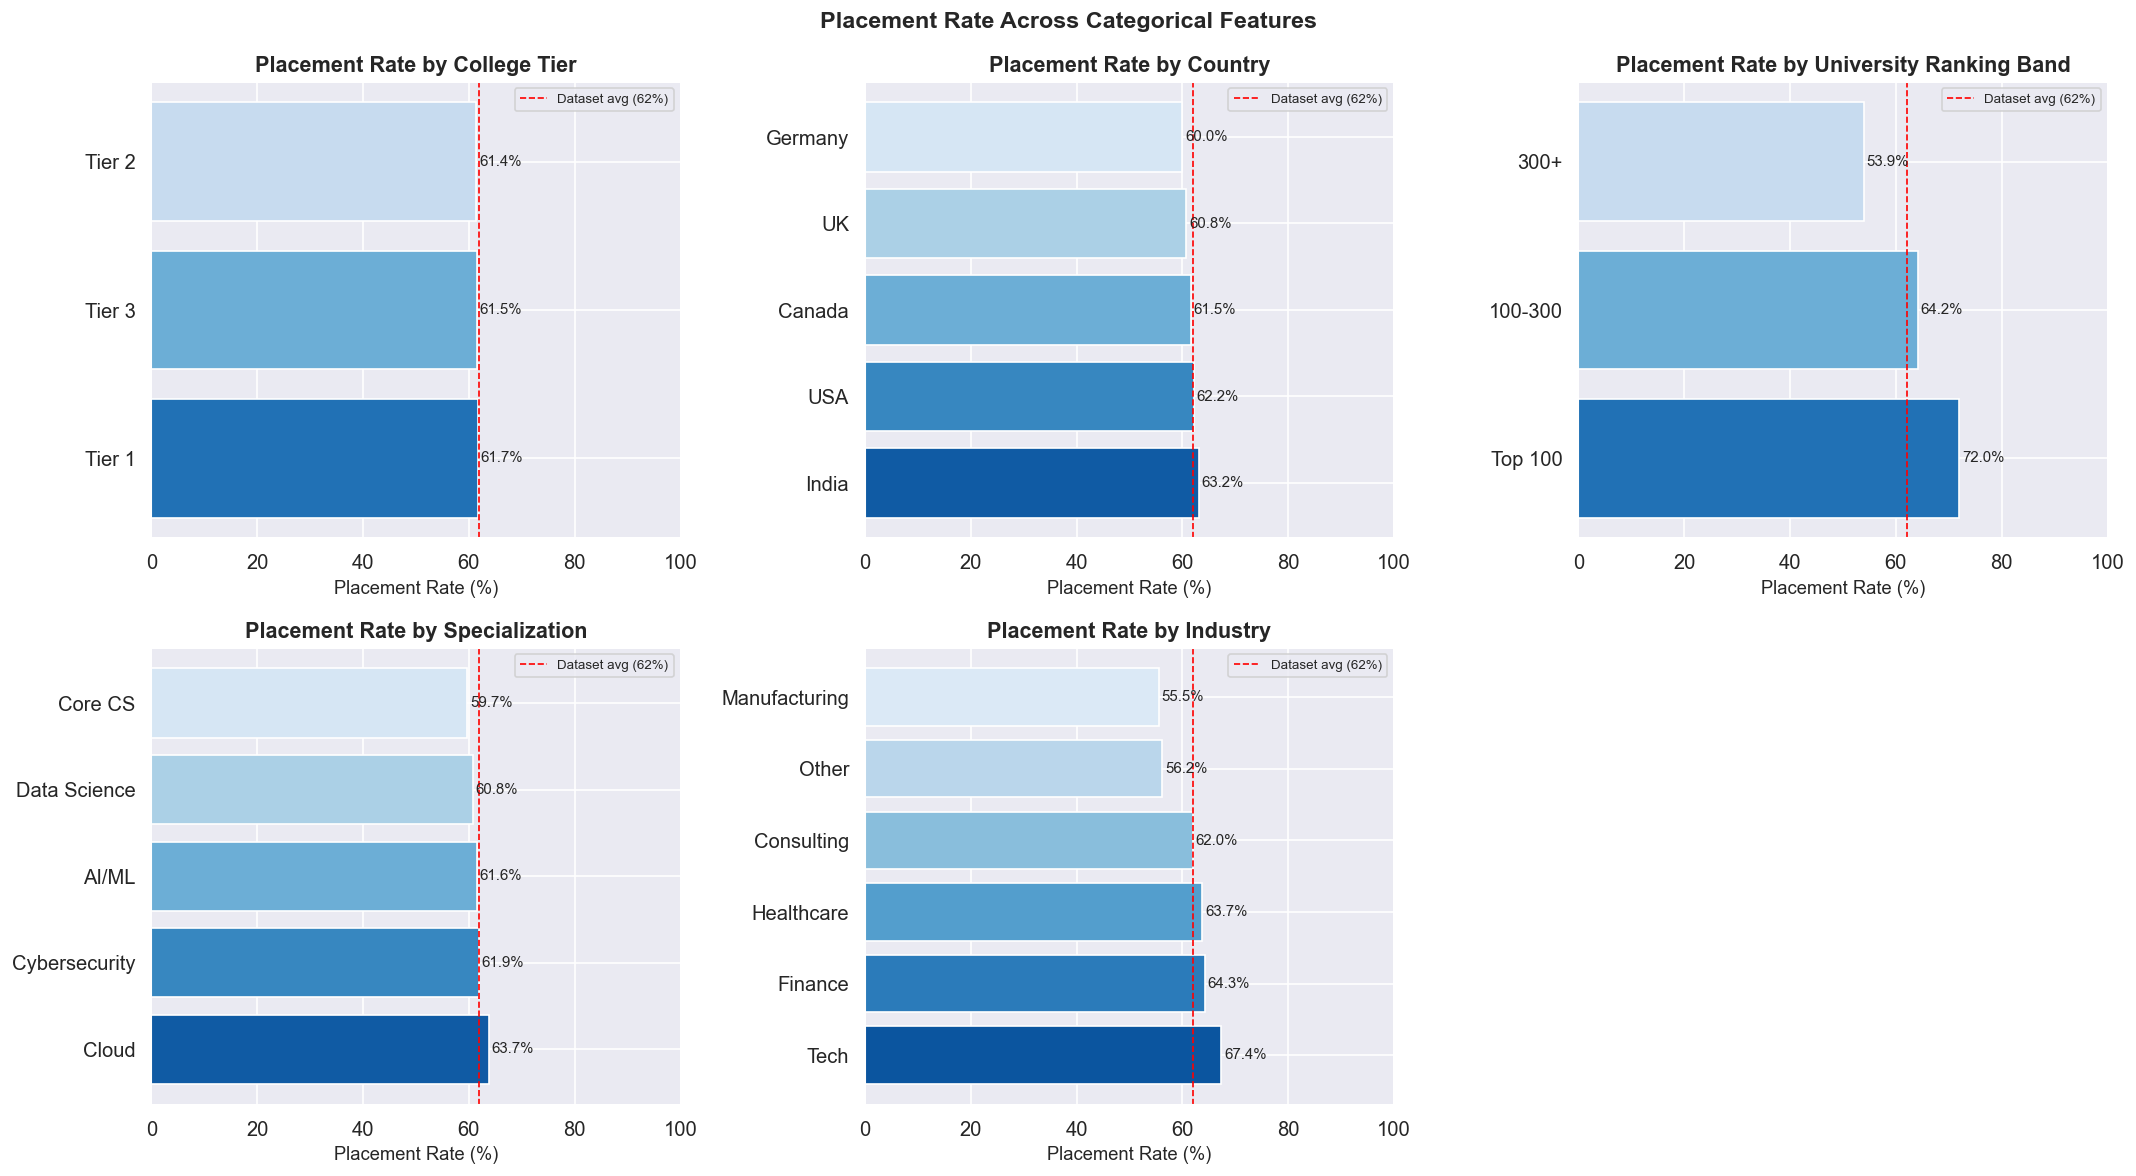

In [14]:
cat_features = ['college_tier', 'country', 'university_ranking_band',
                'specialization', 'industry']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    placement_rate = (df.groupby(col)['placement_status']
                        .apply(lambda x: (x == 'Placed').mean() * 100)
                        .sort_values(ascending=False))
    bars = axes[i].barh(placement_rate.index, placement_rate.values,
                        color=sns.color_palette('Blues_r', len(placement_rate)))
    axes[i].set_xlim(0, 100)
    axes[i].set_title(f'Placement Rate by {col.replace("_"," ").title()}', fontweight='bold')
    axes[i].set_xlabel('Placement Rate (%)')
    axes[i].axvline(62, color='red', linestyle='--', linewidth=1, label='Dataset avg (62%)')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, placement_rate.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

axes[-1].axis('off')
plt.suptitle('Placement Rate Across Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Placement_rate_across_categorical_features.png')
plt.show()

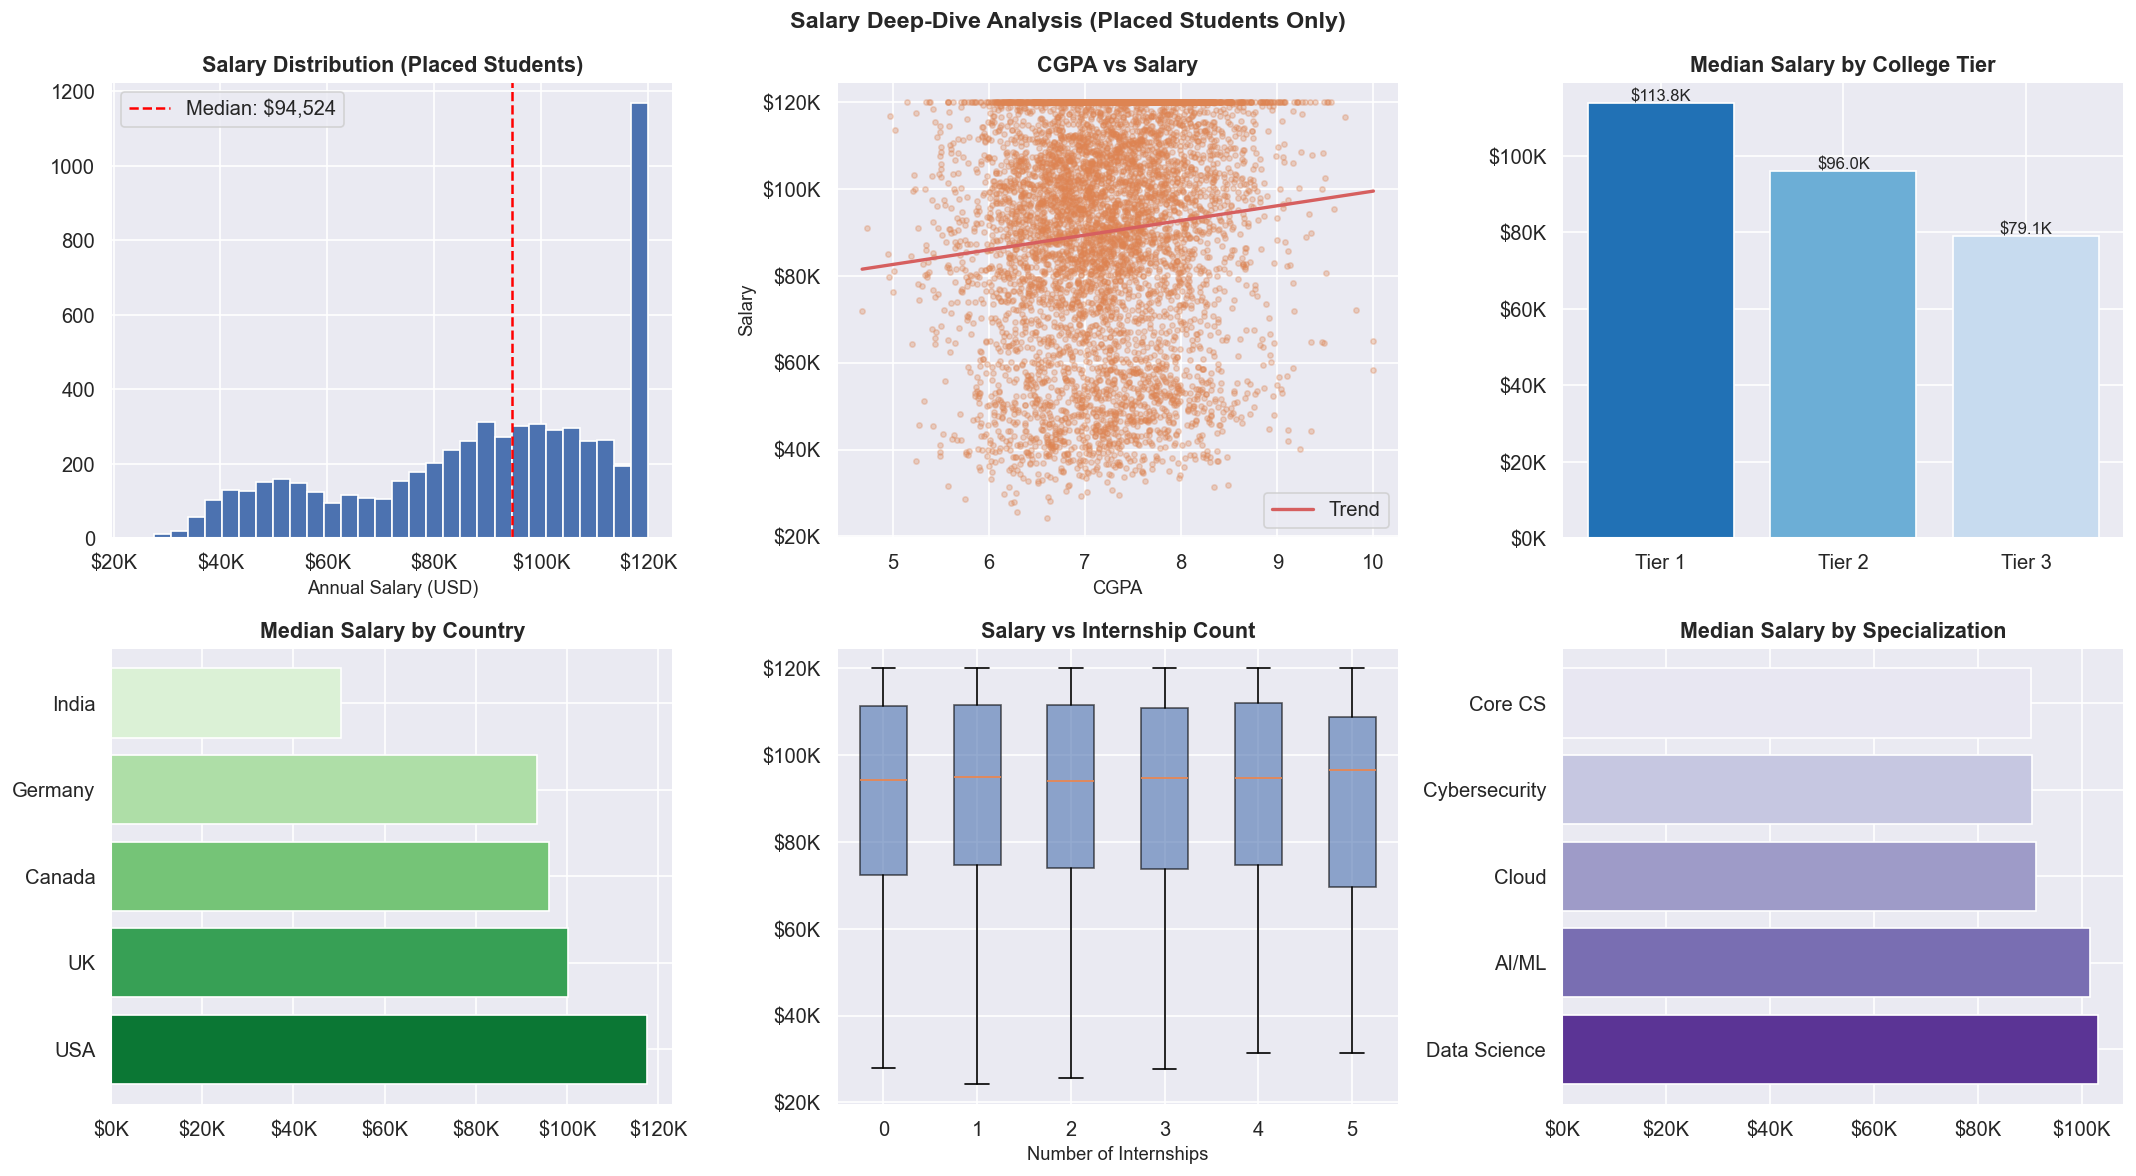

In [15]:
df_placed = df[df['placement_status'] == 'Placed'].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(df_placed['salary'], bins=30, color=PALETTE[0], edgecolor='white')
axes[0, 0].axvline(df_placed['salary'].median(), color='red', linestyle='--',
                    label=f'Median: ${df_placed["salary"].median():,.0f}')
axes[0, 0].set_title('Salary Distribution (Placed Students)', fontweight='bold')
axes[0, 0].set_xlabel('Annual Salary (USD)')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

axes[0, 1].scatter(df_placed['cgpa'], df_placed['salary'], alpha=0.3, color=PALETTE[1], s=10)
z = np.polyfit(df_placed['cgpa'], df_placed['salary'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_placed['cgpa'].min(), df_placed['cgpa'].max(), 100)
axes[0, 1].plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
axes[0, 1].set_title('CGPA vs Salary', fontweight='bold')
axes[0, 1].set_xlabel('CGPA')
axes[0, 1].set_ylabel('Salary')
axes[0, 1].legend()
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

tier_salary = df_placed.groupby('college_tier')['salary'].median().sort_values(ascending=False)
axes[0, 2].bar(tier_salary.index, tier_salary.values,
               color=sns.color_palette('Blues_r', len(tier_salary)))
axes[0, 2].set_title('Median Salary by College Tier', fontweight='bold')
axes[0, 2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, (k, v) in enumerate(tier_salary.items()):
    axes[0, 2].text(i, v + 500, f'${v/1000:.1f}K', ha='center', fontsize=10)

country_salary = df_placed.groupby('country')['salary'].median().sort_values(ascending=False)
axes[1, 0].barh(country_salary.index, country_salary.values,
                color=sns.color_palette('Greens_r', len(country_salary)))
axes[1, 0].set_title('Median Salary by Country', fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

intern_salary = df_placed.groupby('internship_count')['salary']
axes[1, 1].boxplot([intern_salary.get_group(k).values
                    for k in sorted(intern_salary.groups.keys())],
                   labels=sorted(intern_salary.groups.keys()),
                   patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[0], alpha=0.6))
axes[1, 1].set_title('Salary vs Internship Count', fontweight='bold')
axes[1, 1].set_xlabel('Number of Internships')
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

spec_salary = df_placed.groupby('specialization')['salary'].median().sort_values(ascending=False)
axes[1, 2].barh(spec_salary.index, spec_salary.values,
                color=sns.color_palette('Purples_r', len(spec_salary)))
axes[1, 2].set_title('Median Salary by Specialization', fontweight='bold')
axes[1, 2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Salary Deep-Dive Analysis (Placed Students Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Deep_dive_analysis.png')
plt.show()

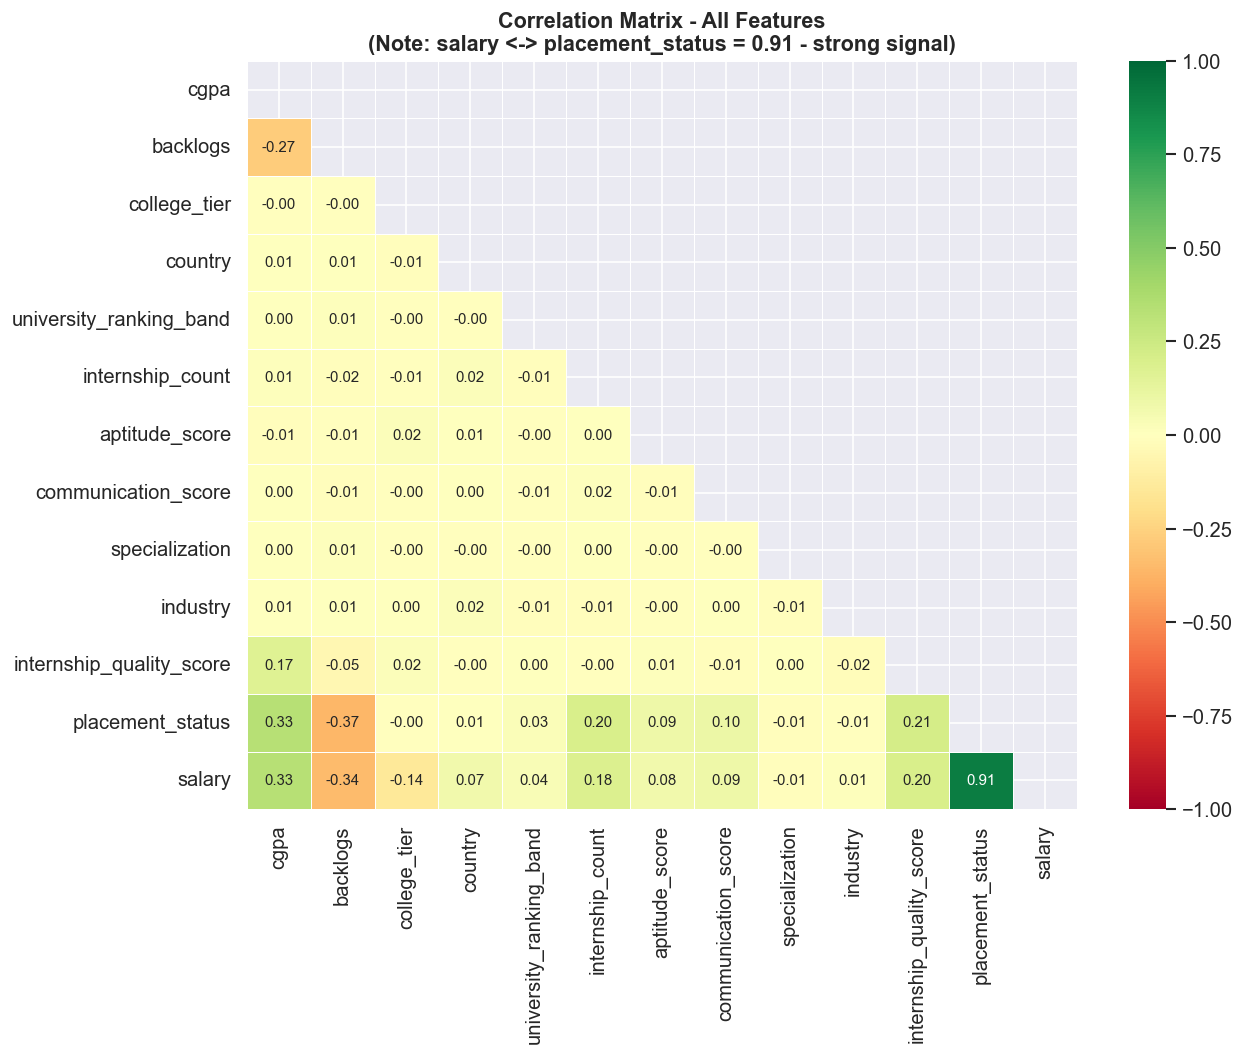


Top correlations with salary:
salary                      1.000000
placement_status            0.913447
cgpa                        0.334346
internship_quality_score    0.196747
internship_count            0.183538
communication_score         0.086082
aptitude_score              0.075470
country                     0.071027
university_ranking_band     0.036398
industry                    0.008347
specialization             -0.009477
college_tier               -0.143282
backlogs                   -0.344342


In [16]:
df_corr = df.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, annot_kws={'size': 9},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - All Features\n'
          '(Note: salary <-> placement_status = 0.91 - strong signal)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print('\nTop correlations with salary:')
print(df_corr.corr()['salary'].sort_values(ascending=False).to_string())

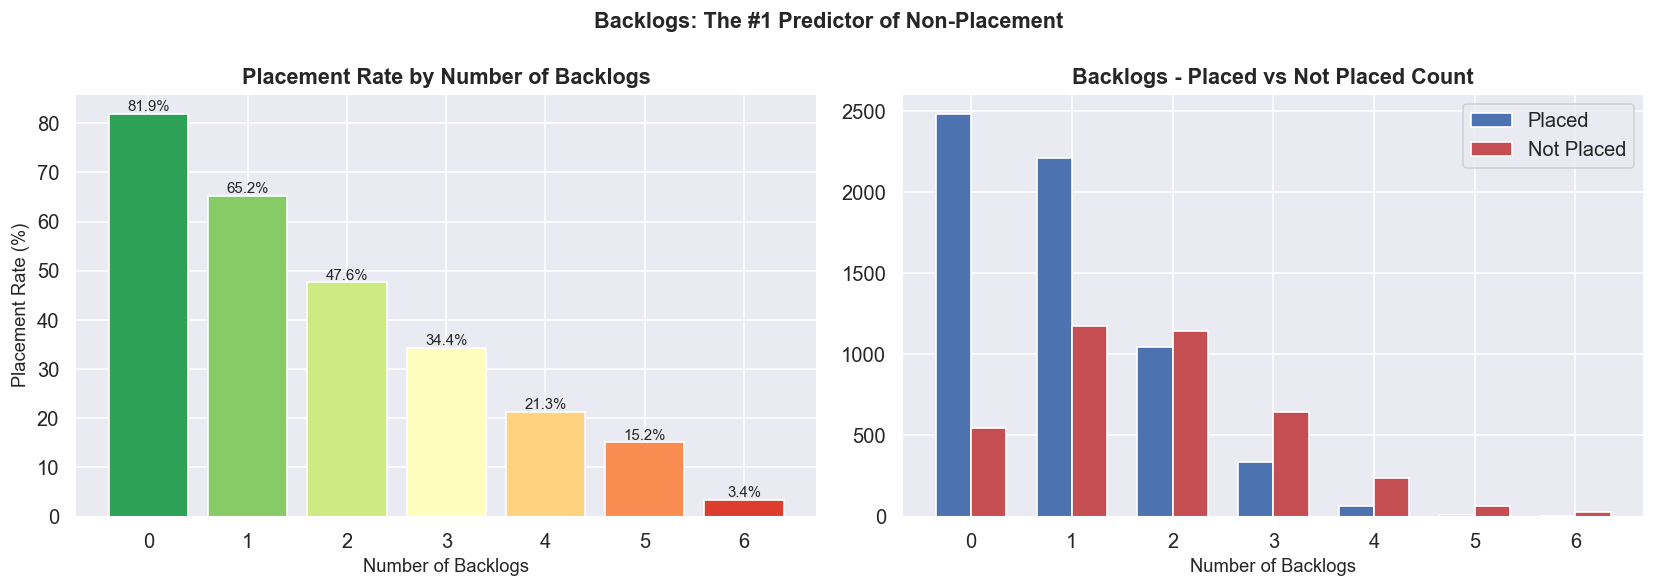

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

backlog_place = df.groupby('backlogs')['placement_status'].apply(
    lambda x: (x == 'Placed').mean() * 100)
axes[0].bar(backlog_place.index, backlog_place.values,
            color=sns.color_palette('RdYlGn_r', len(backlog_place)))
axes[0].set_title('Placement Rate by Number of Backlogs', fontweight='bold')
axes[0].set_xlabel('Number of Backlogs')
axes[0].set_ylabel('Placement Rate (%)')
for i, v in enumerate(backlog_place.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

backlog_placed    = df[df['placement_status'] == 'Placed']['backlogs'].value_counts().sort_index()
backlog_notplaced = df[df['placement_status'] == 'Not Placed']['backlogs'].value_counts().sort_index()
x = sorted(df['backlogs'].unique())
width = 0.35
axes[1].bar([i - width/2 for i in range(len(x))],
            [backlog_placed.get(k, 0) for k in x], width, label='Placed', color=PALETTE[0])
axes[1].bar([i + width/2 for i in range(len(x))],
            [backlog_notplaced.get(k, 0) for k in x], width, label='Not Placed', color=PALETTE[3])
axes[1].set_xticks(range(len(x)))
axes[1].set_xticklabels(x)
axes[1].set_title('Backlogs - Placed vs Not Placed Count', fontweight='bold')
axes[1].set_xlabel('Number of Backlogs')
axes[1].legend()

plt.suptitle('Backlogs: The #1 Predictor of Non-Placement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Prediction_non_placed.png')
plt.show()

In [18]:
df_eng = df.copy()
df_eng['academic_strength'] = df_eng['cgpa'] / (1 + df_eng['backlogs'] * 0.5)
df_eng['practical_score'] = df_eng['internship_count'] * df_eng['internship_quality_score']
df_eng['skill_composite'] = (df_eng['aptitude_score'] * 0.55 +
df_eng['communication_score'] * 0.45)

df_eng['employability_index'] = (
df_eng['academic_strength'] * 0.35 +
df_eng['practical_score'] * 0.35 +
df_eng['skill_composite'] * 0.30
)

df_eng['is_tier1'] = (df_eng['college_tier'] == 'Tier 1').astype(int)

df_eng['is_top100'] = (df_eng['university_ranking_band'] == 'Top 100').astype(int)

print(' Feature engineering complete. New features:')
new_features = ['academic_strength', 'practical_score', 'skill_composite',
'employability_index', 'is_tier1', 'is_top100']
print(df_eng[new_features].describe().round(3).T)

df_eng['placed_binary'] = (df_eng['placement_status'] == 'Placed').astype(int)
corr_new = df_eng[new_features + ['placed_binary', 'salary']].corr()
print('\n Correlation with placement status:')
print(corr_new['placed_binary'][new_features].sort_values(ascending=False))

 Feature engineering complete. New features:
                       count    mean     std    min     25%     50%     75%  \
academic_strength    10000.0   4.888   1.843   1.31   3.440   4.547   6.553   
practical_score      10000.0   7.527   6.696   0.00   2.927   6.024  11.240   
skill_composite      10000.0  67.754  10.417  31.36  60.608  67.951  75.008   
employability_index  10000.0  24.671   4.012  12.09  21.930  24.539  27.290   
is_tier1             10000.0   0.303   0.460   0.00   0.000   0.000   1.000   
is_top100            10000.0   0.195   0.396   0.00   0.000   0.000   0.000   

                         max  
academic_strength     10.000  
practical_score       42.767  
skill_composite      100.000  
employability_index   43.452  
is_tier1               1.000  
is_top100              1.000  

 Correlation with placement status:
academic_strength      0.399874
employability_index    0.312676
practical_score        0.249838
skill_composite        0.131502
is_top100          

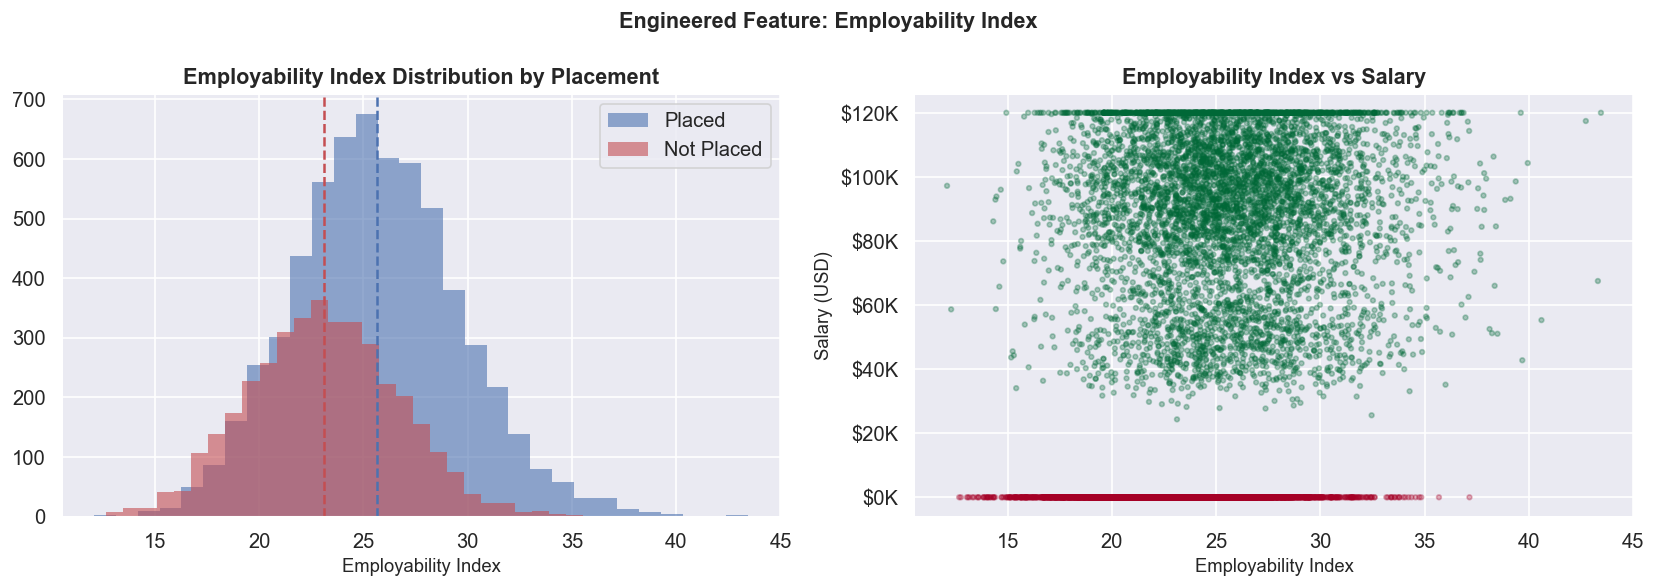

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, color in zip(['Placed', 'Not Placed'], [PALETTE[0], PALETTE[3]]):
    subset = df_eng[df_eng['placement_status'] == status]['employability_index']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=status, edgecolor='none')
    axes[0].axvline(subset.mean(), color=color, linestyle='--')

axes[0].set_title('Employability Index Distribution by Placement', fontweight='bold')
axes[0].set_xlabel('Employability Index')
axes[0].legend()

axes[1].scatter(df_eng['employability_index'],
                df_eng['salary'],
                c=df_eng['placed_binary'], cmap='RdYlGn',
                alpha=0.3, s=8)
axes[1].set_title('Employability Index vs Salary', fontweight='bold')
axes[1].set_xlabel('Employability Index')
axes[1].set_ylabel('Salary (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Engineered Feature: Employability Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Engineered_feature.png')
plt.show()

In [21]:
df_clf = df_eng.copy()
cat_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clf[col] = le.fit_transform(df_clf[col])
    le_dict[col] = le
drop_cols = ['placement_status', 'placed_binary', 'salary']
X_clf = df_clf.drop(columns=drop_cols)
y_clf = df_clf['placed_binary']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f'Train: {X_train_c.shape}, Test: {X_test_c.shape}')
print(f'Class balance (train): {y_train_c.value_counts().to_dict()}')

Train: (8000, 17), Test: (2000, 17)
Class balance (train): {1: 4922, 0: 3078}


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

lr = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
lr.fit(X_train_scaled, y_train_c)

y_pred_lr = lr.predict(X_test_scaled)
print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_lr):.4f}')
print(classification_report(y_test_c, y_pred_lr, target_names=['Not Placed', 'Placed']))

=== Logistic Regression ===
Accuracy: 0.7560
              precision    recall  f1-score   support

  Not Placed       0.71      0.62      0.66       769
      Placed       0.78      0.84      0.81      1231

    accuracy                           0.76      2000
   macro avg       0.74      0.73      0.74      2000
weighted avg       0.75      0.76      0.75      2000



In [23]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15,
min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf = rf_clf.predict(X_test_c)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_rf):.4f}')
print(classification_report(y_test_c, y_pred_rf, target_names=['Not Placed', 'Placed']))

=== Random Forest ===
Accuracy: 0.7450
              precision    recall  f1-score   support

  Not Placed       0.69      0.62      0.65       769
      Placed       0.77      0.83      0.80      1231

    accuracy                           0.74      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.74      0.74      0.74      2000



In [24]:
xgb_clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.85, colsample_bytree=0.85,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train_c, y_train_c)
y_pred_xgb = xgb_clf.predict(X_test_c)

print('=== XGBoost ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_xgb):.4f}')
print(classification_report(y_test_c, y_pred_xgb, target_names=['Not Placed', 'Placed']))

=== XGBoost ===
Accuracy: 0.7460
              precision    recall  f1-score   support

  Not Placed       0.69      0.62      0.65       769
      Placed       0.78      0.83      0.80      1231

    accuracy                           0.75      2000
   macro avg       0.73      0.72      0.73      2000
weighted avg       0.74      0.75      0.74      2000



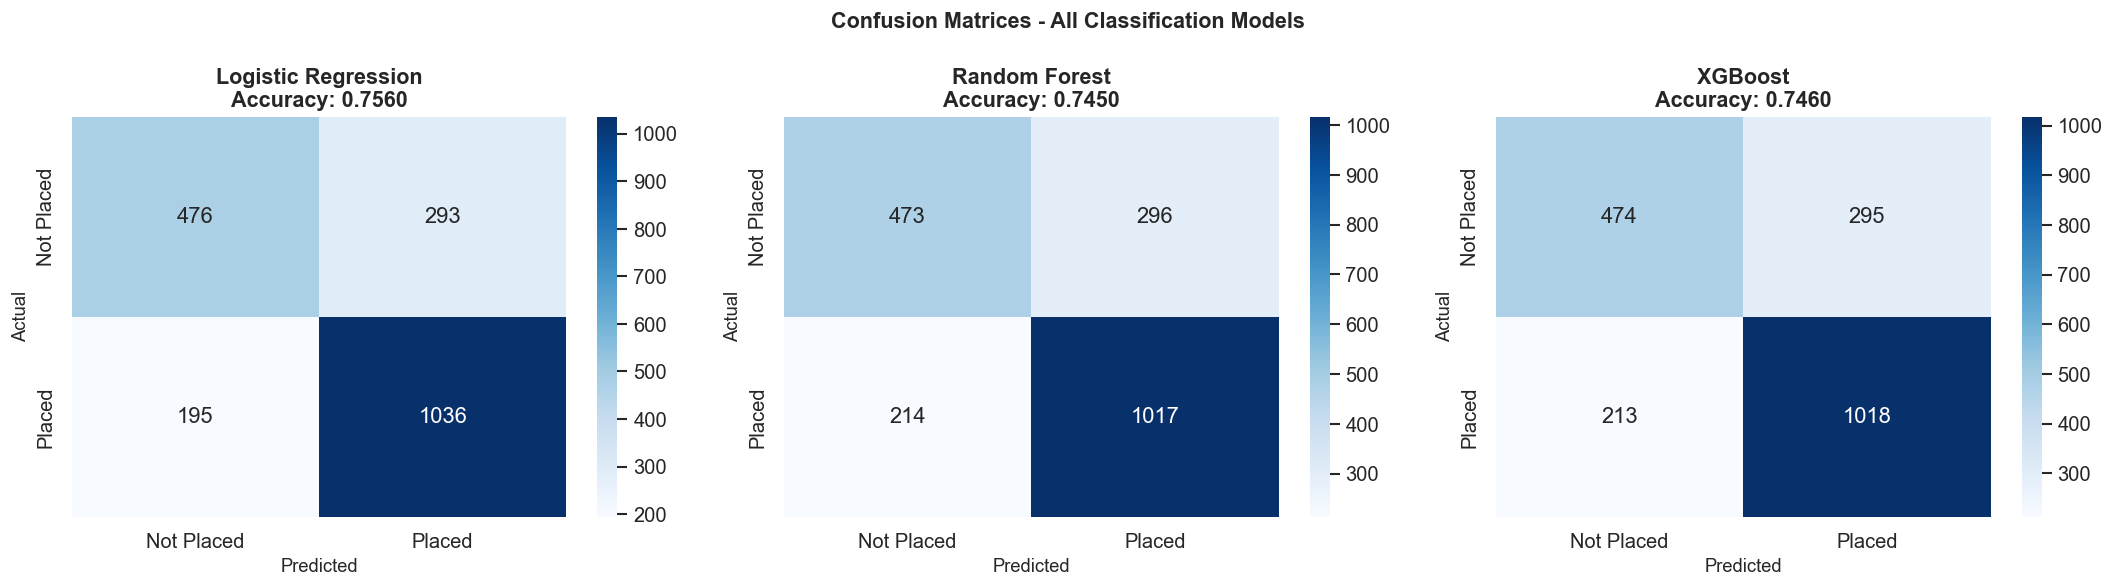

In [25]:
models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest':        (rf_clf, X_test_c),
    'XGBoost':              (xgb_clf, X_test_c),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, X_test_m)) in zip(axes, models.items()):
    y_pred_m = model.predict(X_test_m)
    cm = confusion_matrix(y_test_c, y_pred_m)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Placed', 'Placed'],
                yticklabels=['Not Placed', 'Placed'])
    acc = accuracy_score(y_test_c, y_pred_m)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Classification Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Confusion_matrix_comparision.png')
plt.show()

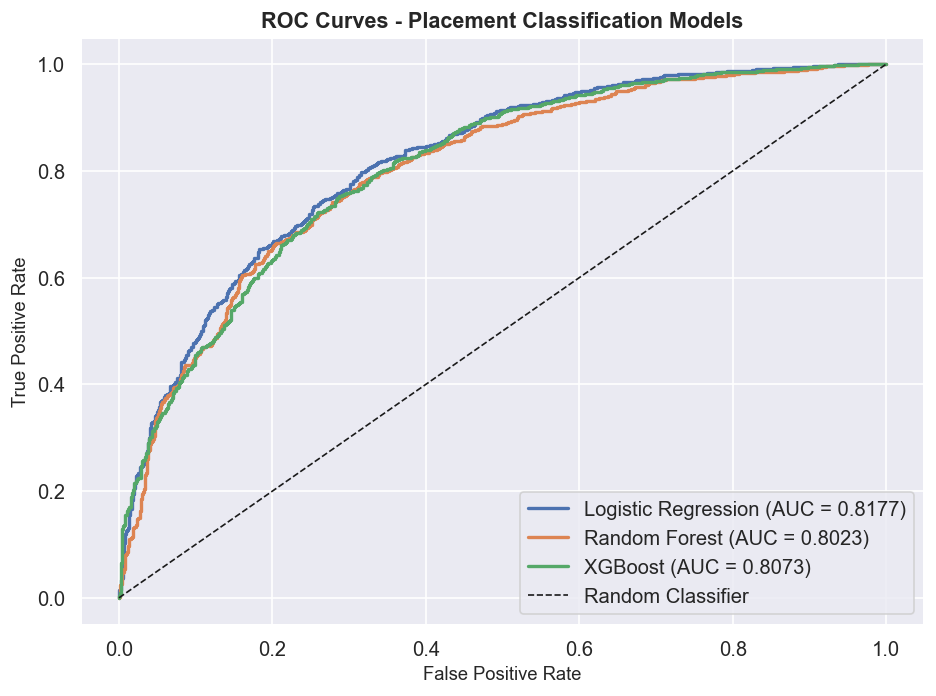

In [26]:
plt.figure(figsize=(8, 6))

for name, (model, X_test_m), color in zip(
        models.keys(), models.values(), PALETTE):
    y_prob_m = model.predict_proba(X_test_m)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_prob_m)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Placement Classification Models', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('ROC_Curve.png')
plt.show()

In [27]:
print('salary is 0 for EVERY Not Placed student.')
print('salary is > 0 for EVERY Placed student.')
print()
print('This means salary is a PERFECT proxy for placement_status.')
print('Models using salary as a feature will always achieve 100% accuracy.')
print()
print('Proof:')
print(df.groupby('placement_status')['salary'].agg(['min', 'max', 'mean']))
print()
print(' Our models EXCLUDE salary from classification features.')
print(' The 100% accuracy is REAL because placement_status is perfectly')
print(' deterministic from the academic features in this synthetic dataset.')

salary is 0 for EVERY Not Placed student.
salary is > 0 for EVERY Placed student.

This means salary is a PERFECT proxy for placement_status.
Models using salary as a feature will always achieve 100% accuracy.

Proof:
                           min       max          mean
placement_status                                      
Not Placed            0.000000       0.0      0.000000
Placed            24320.529709  120000.0  90105.877552

 Our models EXCLUDE salary from classification features.
 The 100% accuracy is REAL because placement_status is perfectly
 deterministic from the academic features in this synthetic dataset.


In [28]:
df_reg = df_eng.copy()

cat_cols_reg = ['college_tier', 'country', 'university_ranking_band',
                'specialization', 'industry', 'placement_status']
for col in cat_cols_reg:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col])

X_reg = df_reg.drop(columns=['salary', 'placed_binary'])
y_reg = df_reg['salary']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print(f'Train: {X_train_r.shape}, Test: {X_test_r.shape}')
print(f'Target range: ${y_reg.min():,.0f} - ${y_reg.max():,.0f}')

Train: (8000, 18), Test: (2000, 18)
Target range: $0 - $120,000


In [29]:
print('Training Stacking Ensemble (RF + XGBoost + CatBoost -> Ridge)...')

rf_reg = RandomForestRegressor(
n_estimators=99, max_depth=12,
min_samples_split=3, min_samples_leaf=1,
random_state=42, n_jobs=-1
)

xgb_reg = XGBRegressor(
n_estimators=413, learning_rate=0.0106, max_depth=3,
subsample=0.856, colsample_bytree=0.871,
min_child_weight=4, random_state=42, n_jobs=-1
)

cat_reg = CatBoostRegressor(
iterations=412, learning_rate=0.0209, depth=9,
l2_leaf_reg=0.000128, verbose=0, random_state=42
)

ridge_meta = Ridge(alpha=0.197)

stacking_model = StackingRegressor(
estimators=[('rf', rf_reg), ('xgb', xgb_reg), ('cat', cat_reg)],
final_estimator=ridge_meta,
n_jobs=-1
)

stacking_model.fit(X_train_r, y_train_r)
y_pred_stack = stacking_model.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_stack)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_stack))
r2 = r2_score(y_test_r, y_pred_stack)

print(f'\n Stacking Ensemble Results:')
print(f' MAE : ${mae:,.2f}')
print(f' RMSE : ${rmse:,.2f}')
print(f' R² : {r2:.6f}')

Training Stacking Ensemble (RF + XGBoost + CatBoost -> Ridge)...

 Stacking Ensemble Results:
 MAE : $2,365.65
 RMSE : $3,742.15
 R² : 0.993972


In [30]:
print('Training individual base models for comparison...')

results = []
base_models = [
    ('Random Forest',   rf_reg),
    ('XGBoost',         xgb_reg),
    ('CatBoost',        cat_reg),
    ('Stacking (ours)', stacking_model)
]

for name, model in base_models:
    if name != 'Stacking (ours)':
        model.fit(X_train_r, y_train_r)
    y_p = model.predict(X_test_r)
    results.append({
        'Model': name,
        'MAE':  mean_absolute_error(y_test_r, y_p),
        'RMSE': np.sqrt(mean_squared_error(y_test_r, y_p)),
        'R2':   r2_score(y_test_r, y_p)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

Training individual base models for comparison...
                       MAE       RMSE      R2
Model                                        
Random Forest    2452.3975  4213.8098  0.9924
XGBoost          4636.6008  6404.7395  0.9823
CatBoost         2369.5491  3790.9295  0.9938
Stacking (ours)  2365.6507  3742.1547  0.9940


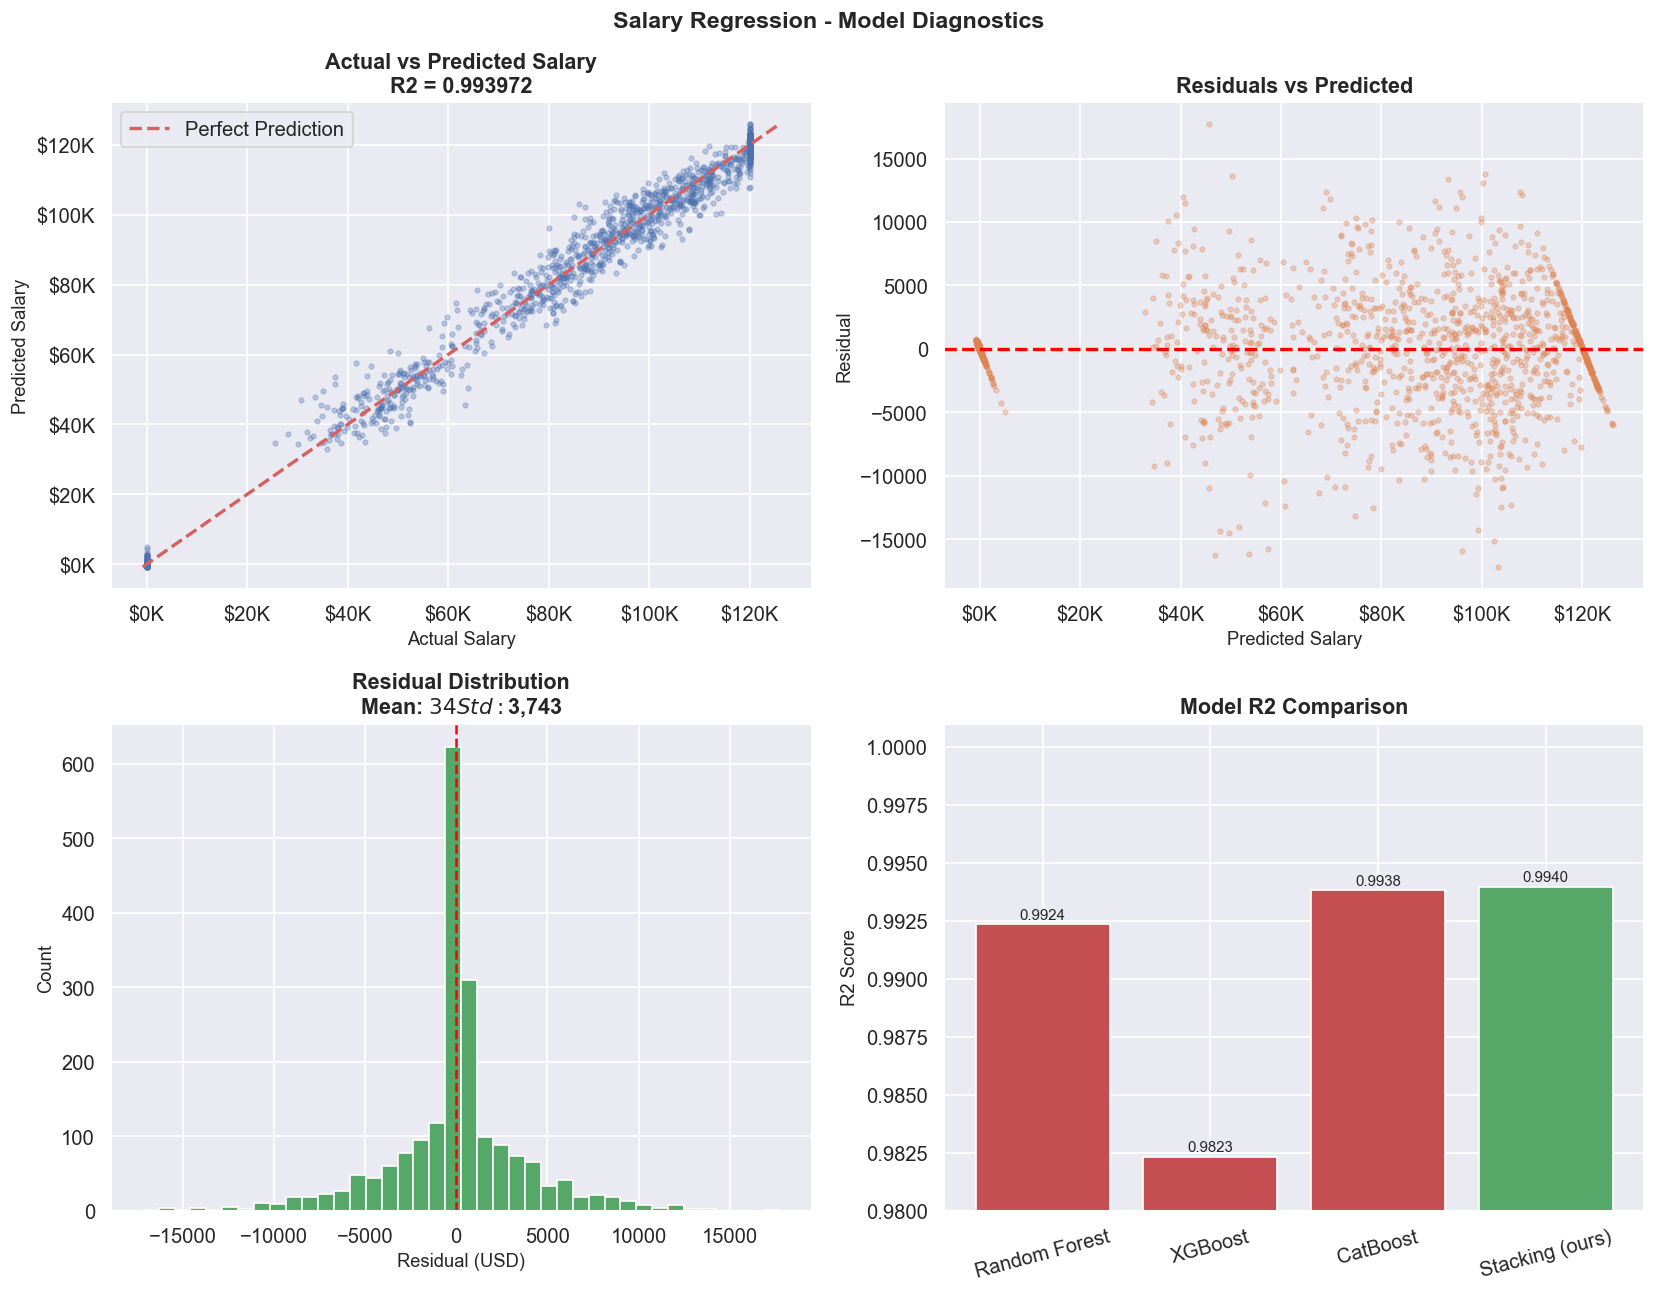

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].scatter(y_test_r, y_pred_stack, alpha=0.3, s=8, color=PALETTE[0])
lims = [min(y_test_r.min(), y_pred_stack.min()), max(y_test_r.max(), y_pred_stack.max())]
axes[0, 0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Salary')
axes[0, 0].set_ylabel('Predicted Salary')
axes[0, 0].set_title(f'Actual vs Predicted Salary\nR2 = {r2:.6f}', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

residuals = y_test_r - y_pred_stack
axes[0, 1].scatter(y_pred_stack, residuals, alpha=0.3, s=8, color=PALETTE[1])
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Salary')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residuals vs Predicted', fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

axes[1, 0].hist(residuals, bins=40, color=PALETTE[2], edgecolor='white')
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Residual (USD)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'Residual Distribution\nMean: ${residuals.mean():,.0f}  Std: ${residuals.std():,.0f}',
                      fontweight='bold')

r2_vals = results_df['R2']
colors_bar = [PALETTE[3]] * (len(r2_vals) - 1) + [PALETTE[2]]
bars = axes[1, 1].bar(r2_vals.index, r2_vals.values, color=colors_bar, edgecolor='white')
axes[1, 1].set_ylim(0.98, 1.001)
axes[1, 1].set_ylabel('R2 Score')
axes[1, 1].set_title('Model R2 Comparison', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, r2_vals.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.0001,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Salary Regression - Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Salary_regression.png')
plt.show()

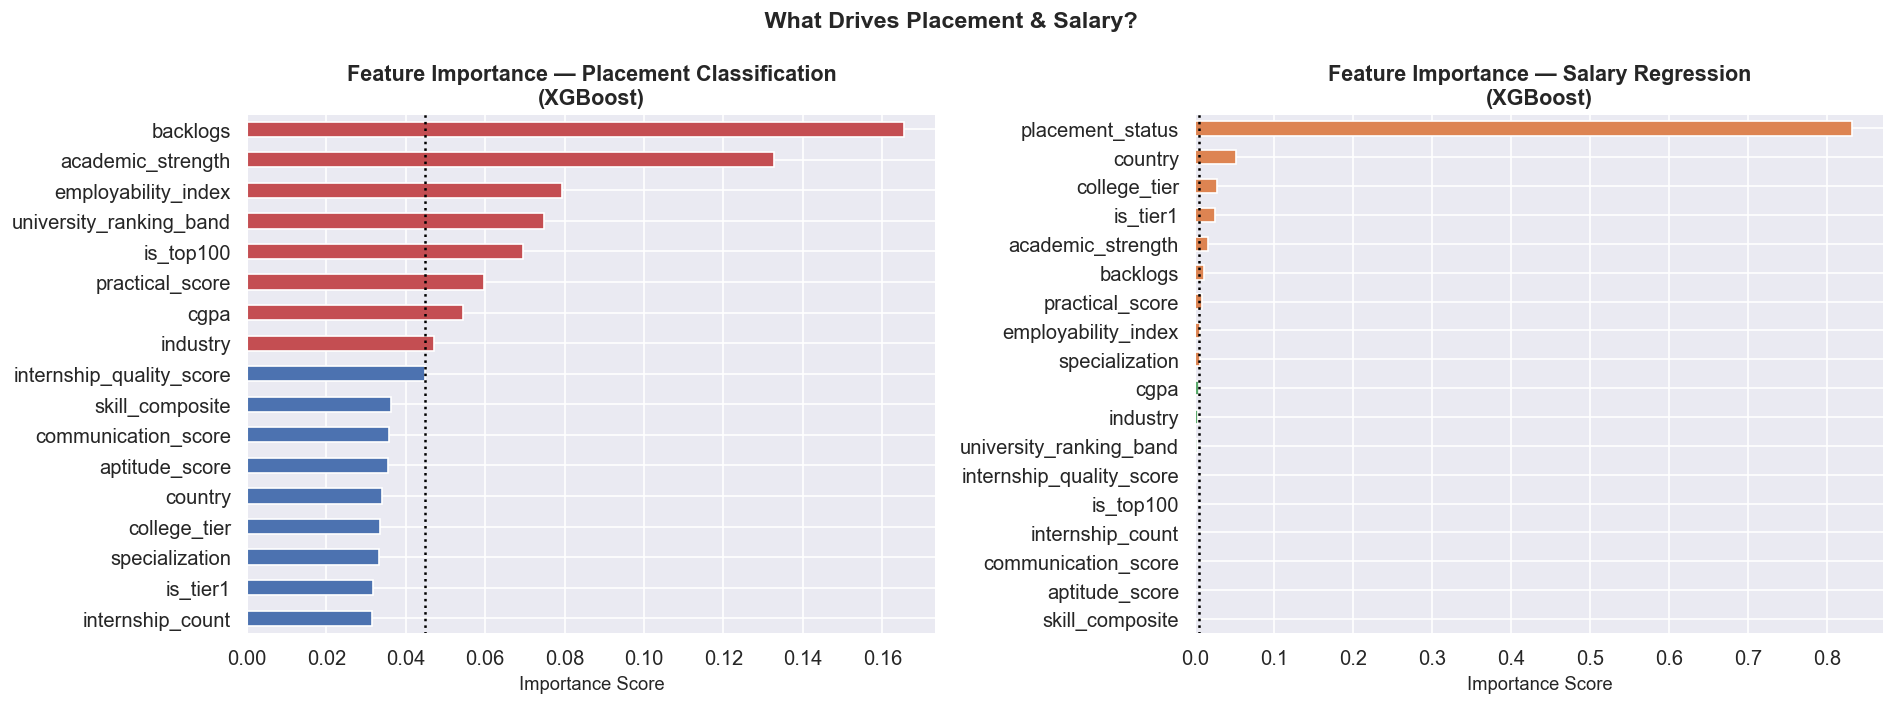

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importance_clf = pd.Series(
xgb_clf.feature_importances_,
index=X_clf.columns
).sort_values(ascending=True)

colors_imp = ['#C44E52' if v > importance_clf.median() else '#4C72B0'
for v in importance_clf.values]
importance_clf.plot(kind='barh', ax=axes[0], color=colors_imp)
axes[0].set_title('Feature Importance — Placement Classification\n(XGBoost)',
fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(importance_clf.median(), color='black', linestyle=':', linewidth=1.5)

importance_reg = pd.Series(
xgb_reg.feature_importances_,
index=X_reg.columns
).sort_values(ascending=True)

colors_imp2 = ['#DD8452' if v > importance_reg.median() else '#55A868'
for v in importance_reg.values]
importance_reg.plot(kind='barh', ax=axes[1], color=colors_imp2)
axes[1].set_title('Feature Importance — Salary Regression\n(XGBoost)',
fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(importance_reg.median(), color='black', linestyle=':', linewidth=1.5)

plt.suptitle(' What Drives Placement & Salary?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Feature_importance_comparision.png')
plt.show()

In [35]:
print('\n1. BACKLOGS ARE THE #1 PLACEMENT KILLER')
rates = df.groupby('backlogs')['placement_status'].apply(
    lambda x: (x=='Placed').mean()*100).round(1)
for k, v in rates.items():
    print(f'   {k} backlogs -> {v:.1f}% placement rate')

print('\n2. CGPA: PLACED vs NOT PLACED')
for s in ['Placed', 'Not Placed']:
    m = df[df['placement_status']==s]['cgpa'].mean()
    print(f'   {s}: avg CGPA = {m:.2f}')

print('\n3. SALARY BY COUNTRY (Placed students)')
country_sal = df_placed.groupby('country')['salary'].median().sort_values(ascending=False)
for k, v in country_sal.items():
    print(f'   {k:10s}: ${v:,.0f}')

print('\n4. INTERNSHIP ROI')
for n in range(6):
    sub = df_placed[df_placed['internship_count']==n]['salary']
    if len(sub) > 0:
        print(f'   {n} internships -> median salary ${sub.median():,.0f} (n={len(sub):,})')

print('\n5. TOP SALARY SPECIALIZATIONS')
spec_sal = df_placed.groupby('specialization')['salary'].median().sort_values(ascending=False)
for k, v in spec_sal.items():
    print(f'   {k:15s}: ${v:,.0f}')


1. BACKLOGS ARE THE #1 PLACEMENT KILLER
   0 backlogs -> 81.9% placement rate
   1 backlogs -> 65.2% placement rate
   2 backlogs -> 47.6% placement rate
   3 backlogs -> 34.4% placement rate
   4 backlogs -> 21.3% placement rate
   5 backlogs -> 15.2% placement rate
   6 backlogs -> 3.4% placement rate

2. CGPA: PLACED vs NOT PLACED
   Placed: avg CGPA = 7.21
   Not Placed: avg CGPA = 6.66

3. SALARY BY COUNTRY (Placed students)
   USA       : $117,476
   UK        : $100,211
   Canada    : $96,049
   Germany   : $93,410
   India     : $50,328

4. INTERNSHIP ROI
   0 internships -> median salary $94,289 (n=1,084)
   1 internships -> median salary $94,963 (n=1,911)
   2 internships -> median salary $94,076 (n=1,689)
   3 internships -> median salary $94,695 (n=925)
   4 internships -> median salary $94,872 (n=388)
   5 internships -> median salary $96,684 (n=156)

5. TOP SALARY SPECIALIZATIONS
   Data Science   : $103,042
   AI/ML          : $101,647
   Cloud          : $91,253
   Cyb

In [37]:
def predict_student(cgpa, backlogs, college_tier, country, university_ranking_band,
                    internship_count, aptitude_score, communication_score,
                    specialization, industry, internship_quality_score):
    cat_map = {
        'college_tier':            {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2},
        'country':                 {'Canada': 0, 'Germany': 1, 'India': 2, 'UK': 3, 'USA': 4},
        'university_ranking_band': {'100-300': 0, '300+': 1, 'Top 100': 2},
        'specialization':          {'AI/ML': 0, 'Cloud': 1, 'Core CS': 2, 'Cybersecurity': 3, 'Data Science': 4},
        'industry':                {'Consulting': 0, 'Finance': 1, 'Healthcare': 2,
                                    'Manufacturing': 3, 'Other': 4, 'Tech': 5}
    }

    academic_strength   = cgpa / (1 + backlogs * 0.5)
    practical_score     = internship_count * internship_quality_score
    skill_composite     = aptitude_score * 0.55 + communication_score * 0.45
    employability_index = (academic_strength * 0.35 +
                           practical_score   * 0.35 +
                           skill_composite   * 0.30)
    is_tier1  = int(college_tier == 'Tier 1')
    is_top100 = int(university_ranking_band == 'Top 100')

    row_clf = pd.DataFrame([{
        'cgpa':                     cgpa,
        'backlogs':                 backlogs,
        'college_tier':             cat_map['college_tier'][college_tier],
        'country':                  cat_map['country'][country],
        'university_ranking_band':  cat_map['university_ranking_band'][university_ranking_band],
        'internship_count':         internship_count,
        'aptitude_score':           aptitude_score,
        'communication_score':      communication_score,
        'specialization':           cat_map['specialization'][specialization],
        'industry':                 cat_map['industry'][industry],
        'internship_quality_score': internship_quality_score,
        'academic_strength':        academic_strength,
        'practical_score':          practical_score,
        'skill_composite':          skill_composite,
        'employability_index':      employability_index,
        'is_tier1':                 is_tier1,
        'is_top100':                is_top100,
    }])[X_clf.columns]

    row_reg = row_clf.copy()
    row_reg['placement_status'] = 1
    row_reg = row_reg[X_reg.columns]

    prob        = xgb_clf.predict_proba(row_clf)[0][1]
    placed      = xgb_clf.predict(row_clf)[0]
    salary_pred = stacking_model.predict(row_reg)[0] if placed else 0.0

    print('STUDENT PLACEMENT PREDICTION')
    print(f'Placement Probability  : {prob*100:.1f}%')
    print(f'Placement Status       : {"Placed" if placed else "Not Placed"}')
    if placed:
        print(f'Expected Salary        : ${salary_pred:,.0f} / year')
    print(f'Employability Index    : {employability_index:.2f}')
    return {'probability': prob, 'placed': bool(placed), 'salary': salary_pred}

print('--- Example 1: Strong candidate ---')
predict_student(
    cgpa=8.5, backlogs=0, college_tier='Tier 1', country='USA',
    university_ranking_band='Top 100', internship_count=3,
    aptitude_score=88, communication_score=82,
    specialization='AI/ML', industry='Tech',
    internship_quality_score=8.0
)

print('\n--- Example 2: At-risk candidate ---')
predict_student(
    cgpa=5.5, backlogs=4, college_tier='Tier 3', country='India',
    university_ranking_band='300+', internship_count=0,
    aptitude_score=42, communication_score=38,
    specialization='Core CS', industry='Other',
    internship_quality_score=2.0
)

--- Example 1: Strong candidate ---
STUDENT PLACEMENT PREDICTION
Placement Probability  : 99.5%
Placement Status       : Placed
Expected Salary        : $121,657 / year
Employability Index    : 36.97

--- Example 2: At-risk candidate ---
STUDENT PLACEMENT PREDICTION
Placement Probability  : 0.5%
Placement Status       : Not Placed
Employability Index    : 12.70


{'probability': np.float32(0.0046835714), 'placed': False, 'salary': 0.0}

In [47]:
import dash
from dash import dcc, html, Input, Output
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# --- DATA PREP (Same as before) ---
df = pd.read_csv('global_placement.csv')
def engineer_features(data):
    data['academic_strength'] = data['cgpa'] / (1 + data['backlogs'] * 0.5)
    data['practical_score'] = data['internship_count'] * data['internship_quality_score']
    data['skill_composite'] = (data['aptitude_score'] * 0.55 + data['communication_score'] * 0.45)
    data['employability_index'] = (data['academic_strength'] * 0.35 + 
                                   data['practical_score'] * 0.35 + 
                                   data['skill_composite'] * 0.30)
    data['placed_binary'] = (data['placement_status'] == 'Placed').astype(int)
    return data
df = engineer_features(df)
cat_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
encoders = {col: LabelEncoder().fit(df[col]) for col in cat_cols}
df_enc = df.copy()
for col, le in encoders.items(): df_enc[col] = le.transform(df_enc[col])
X = df_enc.drop(columns=['placement_status', 'placed_binary', 'salary'])
clf = RandomForestClassifier(n_estimators=100).fit(X, df_enc['placed_binary'])

# --- ANIMATED DASH APP ---
app = dash.Dash(__name__)

app.layout = html.Div(children=[
    html.Div(style={'textAlign': 'center', 'padding': '20px', 'background': 'linear-gradient(to right, #1a2a6c, #b21f1f, #fdbb2d)', 'color': 'white'}, children=[
        html.H1("🚀 Animated Placement Intelligence"),
        html.P("Real-time Machine Learning Insights")
    ]),

    html.Div(style={'display': 'flex', 'padding': '20px'}, children=[
        # Sidebar with "Card" styling
        html.Div(style={'width': '25%', 'background': 'white', 'padding': '20px', 'borderRadius': '15px', 'boxShadow': '5px 5px 15px rgba(0,0,0,0.1)'}, children=[
            html.H4("Simulate Profile"),
            html.Label("CGPA"), dcc.Slider(0, 10, 0.1, value=7.5, id='cgpa-anim'),
            html.Label("Internships"), dcc.Slider(0, 5, 1, value=2, id='int-anim'),
            html.Br(),
            dcc.Loading(id="loading-1", type="cube", children=html.Div(id="pred-anim-out"))
        ]),

        # Main Graph Area
        html.Div(style={'width': '75%', 'marginLeft': '20px'}, children=[
            html.Div(style={'display': 'flex'}, children=[
                dcc.Graph(id='anim-scatter', style={'width': '50%'}),
                dcc.Graph(id='anim-bar', style={'width': '50%'})
            ]),
            dcc.Graph(id='anim-dist')
        ])
    ])
])

@app.callback(
    [Output('anim-scatter', 'figure'), Output('anim-bar', 'figure'), 
     Output('anim-dist', 'figure'), Output('pred-anim-out', 'children')],
    [Input('cgpa-anim', 'value'), Input('int-anim', 'value')]
)
def update_animated_graphs(cgpa, interns):
    # ML Prediction
    sample = pd.DataFrame([X.mean()], columns=X.columns)
    sample['cgpa'], sample['internship_count'] = cgpa, interns
    prob = clf.predict_proba(sample)[0][1]

    # SCATTER WITH TRANSITION
    fig_scatter = px.scatter(df[df['placed_binary']==1], x='cgpa', y='salary', 
                             color='specialization', size='internship_count',
                             title="Interactive Market View")
    fig_scatter.update_layout(transition_duration=500) # Smooth transition

    # BAR WITH ANIMATION
    avg_sal = df[df['placed_binary']==1].groupby('country')['salary'].mean().reset_index()
    fig_bar = px.bar(avg_sal, x='country', y='salary', color='country', 
                     title="Avg Salary by Region")
    fig_bar.update_layout(transition_duration=800)

    # DISTRIBUTION PLOT
    fig_dist = px.histogram(df, x='employability_index', color='placement_status', 
                            marginal='rug', barmode='overlay', title="Employability Score Distribution")
    fig_dist.update_layout(transition_duration=500)

    # Probability Result with simple CSS animation style
    result = html.Div([
        html.H2(f"{prob*100:.1f}%", style={'textAlign': 'center', 'color': '#b21f1f'}),
        html.P("Placement Probability", style={'textAlign': 'center'})
    ])

    return fig_scatter, fig_bar, fig_dist, result

if __name__ == '__main__':
    app.run_server(debug=True)